# Expanded Sequence Modeling
## Next Steps for Model Improvement
1. Increase the dataset size (current size n = 10-20 sequences which is too small).
2. Add richer features (e.g. hydrophobicity, charge, or molecular weight)
3. Balance the classes (there should be an appropriate distribution of samples from all classifications)
4. Modify prediction criteria (e.g. secondary structure type, or domain presence)

## Expand Dataset: Download Additional Sequences


To build a more robust baseline model and reduce sampling bias, we expand our dataset by including additional antibody-related or immunoglobulin-like structures. 
We specifically select a diverse set across different chain lengths to preserve the versatility goal from our original experimental design.

This step enables:
- Better evaluation of simple features like amino acid composition.
- A stronger foundation for future modeling with more sophisticated architectures.
By... 
- Downloading more PDB_IDs (20-50).
- Re-runing the loading, feature generation, and modeling.
- Evaluate if the accuracy improves beyond random guesses. 



Desired structure doesn't exist
Error: Structure file for 6A9M not found at /Users/test/python/github_scripts/protein_generativeML_design/data/pdb6a9m.ent
Accuracy: 0.875

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.88      1.00      0.93         7

    accuracy                           0.88         8
   macro avg       0.44      0.50      0.47         8
weighted avg       0.77      0.88      0.82         8



/Users/test/miniconda3/envs/protein_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/test/miniconda3/envs/protein_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/test/miniconda3/envs/protein_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr

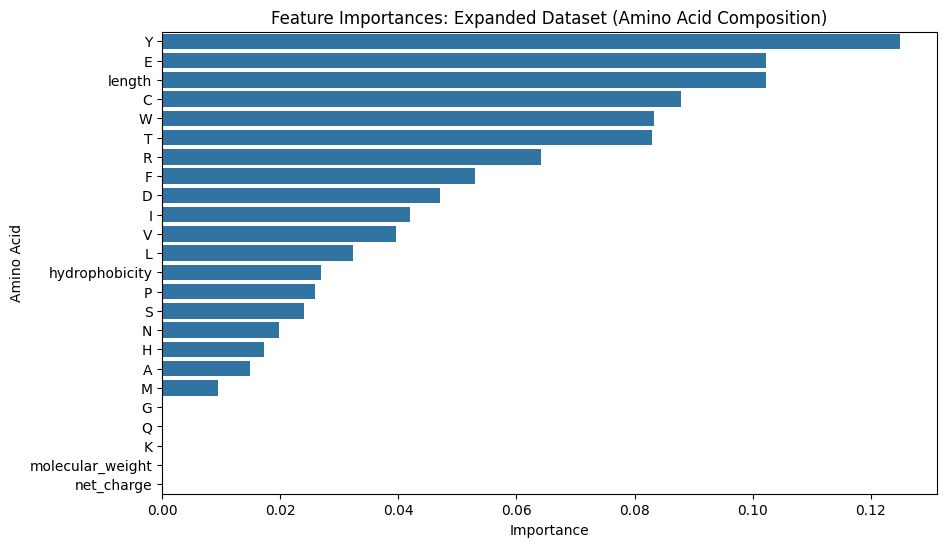

In [36]:
 # Import necessary libraries
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from Bio import PDB
from Bio import SeqIO
from Bio.PDB import Polypeptide
from Bio.PDB import PDBList

pdb_downloader = PDBList()

VALID_AAS = set('ACDEFGHIKLMNPQRSTVWY')
# Hydrophobicity values (Kyte-Doolittle scale)
AA_HYDROPHOBICITY_SCALE = {
    'A': 1.8, 'C': 2.5, 'D': -3.5, 'E': -3.5, 'F': 2.8,
    'G': -0.4, 'H': -3.2, 'I': 4.5, 'K': -3.9, 'L': 3.8,
    'M': 1.9, 'N': -3.5, 'P': -1.6, 'Q': -3.5, 'R': -4.5,
    'S': -0.8, 'T': -0.7, 'V': 4.2, 'W': -0.9, 'Y': -1.3
}
# Molecular weight (approximate, not including modifications)
AA_MOLECULAR_WEIGHT = {
    'A': 89.1, 'C': 121.2, 'D': 133.1, 'E': 147.1, 'F': 165.2,
    'G': 75.1, 'H': 155.2, 'I': 131.2, 'K': 146.2, 'L': 131.2,
    'M': 149.2, 'N': 132.1, 'P': 115.1, 'Q': 146.2, 'R': 174.2,
    'S': 105.1, 'T': 119.1, 'V': 117.1, 'W': 204.2, 'Y': 181.2
}

# Mapping from three-letter to one-letter amino acid codes
THREE_TO_ONE = {
    'ALA': 'A', 'CYS': 'C', 'ASP': 'D', 'GLU': 'E', 'PHE': 'F',
    'GLY': 'G', 'HIS': 'H', 'ILE': 'I', 'LYS': 'K', 'LEU': 'L',
    'MET': 'M', 'ASN': 'N', 'PRO': 'P', 'GLN': 'Q', 'ARG': 'R',
    'SER': 'S', 'THR': 'T', 'VAL': 'V', 'TRP': 'W', 'TYR': 'Y'
}


def compute_aa_composition(seq):
    """Compute amino acid composition vector for a given sequence."""
    counts = {aa: 0 for aa in VALID_AAS}
    for aa in seq:
        if aa in counts:
            counts[aa] += 1
    total = len(seq)
    return np.array([counts[aa] / total for aa in sorted(VALID_AAS)])

def categorize_length(length):
    """Categorize protein chain length."""
    if length < 50:
        return 'short'
    elif length < 150:
        return 'medium'
    else:
        return 'long'

def compute_hydrophobicity(seq):
    scores = [AA_HYDROPHOBICITY_SCALE.get(aa, 0.0) for aa in seq]
    return np.mean(scores) if scores else 0.0

def compute_molecular_weight(seq):
    weights = [AA_MOLECULAR_WEIGHT.get(aa, 0.0) for aa in seq]
    return np.mean(weights) if weights else 0.0

def compute_net_charge(seq):
    positive = sum(seq.count(aa) for aa in 'KRH')
    negative = sum(seq.count(aa) for aa in 'DE')
    return positive - negative


def load_all_fasta_sequences(pdb_ids, data_dir):
    """Load sequences from prepared FASTA files."""
    records = []
    for pdb_id in pdb_ids:
        fasta_path = os.path.join(data_dir, f'{pdb_id}_sequences.fasta')
        if os.path.exists(fasta_path):
            with open(fasta_path, 'r') as f:
                current_id = None
                for line in f:
                    line = line.strip()
                    if line.startswith('>'):
                        current_id = line[1:]  # remove ">"
                    else:
                        records.append({'pdb_chain_id': current_id, 'sequence': line})
        else:
            print(f"Warning: File {fasta_path} not found.")
    return pd.DataFrame(records)


def fetch_fasta_from_pdb(pdb_id):
    """Fetches the FASTA sequence of a given PDB ID from RCSB."""
    url = f"https://www.rcsb.org/fasta/entry/{pdb_id}"
    response = requests.get(url)
    if response.status_code == 200:
        return response.text
    else:
        print(f"Warning: Could not fetch {pdb_id}")
        return None

def save_fasta(pdb_id, save_dir):
    """Save the fetched FASTA to a file."""
    fasta_text = fetch_fasta_from_pdb(pdb_id)
    if fasta_text:
        fasta_path = os.path.join(save_dir, f"{pdb_id}_sequences.fasta")
        with open(fasta_path, 'w') as f:
            f.write(fasta_text)
        print(f"Saved {pdb_id} to {fasta_path}")

def download_and_extract_fasta(pdb_id, data_dir):
    pdbl = PDBList()
    structure_file = pdbl.retrieve_pdb_file(pdb_id, pdir=data_dir, file_format='pdb')
    # Check if the file exists
    if not os.path.exists(structure_file):
        print(f"Error: Structure file for {pdb_id} not found at {structure_file}")
        return
    
    # Parse sequences from structure file
    try:
        records = []
        with open(structure_file, 'r') as f:
            seq = ""
            chain_id = None
            for line in f:
                if line.startswith('ATOM') and line[13:15].strip() == 'CA':
                    resname = line[17:20].strip()
                    chain_id = line[21]
                    if resname in THREE_TO_ONE:
                        seq += THREE_TO_ONE[resname]
            if seq:
                records.append((chain_id, seq))

        # Save extracted sequence to FASTA format
        fasta_path = os.path.join(data_dir, f"{pdb_id}_sequences.fasta")
        with open(fasta_path, 'w') as f:
            for chain_id, seq in records:
                f.write(f">{pdb_id}_{chain_id}\n{seq}\n")
        
        print(f"Saved sequences for {pdb_id} to {fasta_path}")
    except Exception as e:
        print(f"Failed to process {pdb_id}: {e}")


def load_all_fasta_sequences(pdb_ids, data_dir):
    """Load sequences from prepared FASTA files."""
    records = []
    for pdb_id in pdb_ids:
        fasta_file = os.path.join(data_dir, f"{pdb_id}_sequences.fasta")
        if os.path.exists(fasta_file):
            for record in SeqIO.parse(fasta_file, "fasta"):
                records.append({
                    'pdb_id': pdb_id,
                    'chain_id': record.id.split('_')[-1],
                    'sequence': str(record.seq)
                })
    return pd.DataFrame(records)


save_dir = os.path.join(os.getcwd(), 'data')
additional_pdb_ids = [
    '1A8M', 
    '1BRS', 
    '2QMT', 
    '4HHB', 
    '5XNL', 
    '6A9M',
    '6XDG', 
    '6W41', 
    '7BZ5', 
    '7C01', 
    '6DKK',  # Therapeutic antibodies
    '5DK3',
    '6I1F', 
    '6O1I', 
    '6WPS', 
    '7JVA',
    '7AHL']  # Nanobodies and related scaffolds

all_pdb_ids = ['6P8Q', '6H7H', '1N8Z'] + additional_pdb_ids
all_pdb_ids = set(all_pdb_ids)
print(f"Downloading FASTA for n={len(all_pdb_ids)} PDB IDs")
for pdb_id in all_pdb_ids:
    if os.path.exists(os.path.join(save_dir, f"{pdb_id}_sequences.fasta")):
        continue
    else:
        try:
            download_and_extract_fasta(pdb_id, data_dir)
        except Exception as e:
            print(f"Error processing {pdb_id}: {e}")
            # remove pdb_id from list if it fails
            all_pdb_ids.remove(pdb_id)   
            continue

# Load all  sequences
#sequences_df = load_all_fasta_sequences(all_pdb_ids, data_dir)
# Load all sequences again (now including originals + new ones)
expanded_sequences_df = load_all_fasta_sequences(all_pdb_ids, data_dir)

# Add features and create simple labels: short (0) vs long (1)
expanded_sequences_df['length'] = expanded_sequences_df['sequence'].apply(len)
expanded_sequences_df['length_category'] = expanded_sequences_df['length'].apply(categorize_length)
expanded_sequences_df['label'] = (expanded_sequences_df['length'] > 100).astype(int)

# Compute amino acid composition features
composition_features = expanded_sequences_df['sequence'].apply(compute_aa_composition)
composition_df = pd.DataFrame(composition_features.tolist(), columns=sorted(VALID_AAS))

# Final modeling DataFrame
expanded_modeling_df = pd.concat([expanded_sequences_df, composition_df], axis=1)
#  Update the feature matrix with additional biophysical features
expanded_modeling_df['net_charge'] = expanded_modeling_df[
    'sequence'].apply(compute_net_charge)
expanded_modeling_df['hydrophobicity'] = expanded_modeling_df[
    'sequence'].apply(compute_hydrophobicity)
expanded_modeling_df['molecular_weight'] = expanded_modeling_df[
    'sequence'].apply(compute_molecular_weight)
expanded_modeling_df.head()

# Prepare training data
X = np.hstack([
    expanded_modeling_df[sorted(VALID_AAS)].values,
    expanded_modeling_df[[
        'length', 
        'hydrophobicity', 
        'molecular_weight', 
        'net_charge']].values
])
y = expanded_modeling_df['label'].values

feature_names = sorted(VALID_AAS) + [
    'length', 
    'hydrophobicity', 
    'molecular_weight', 
    'net_charge']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)
# Retrain the RandomForestClassifier with the updated feature matrix
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Update feature importances with the correct feature names
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Feature Importances: Expanded Dataset (Amino Acid Composition)')
plt.xlabel('Importance')
plt.ylabel('Amino Acid')
plt.show()




## Adding additional features for model generation 


| Feature | What it tells us |
|:---|:---|
| Amino acid composition | Detailed usage of residues |
| Length | Overall sequence size |
| Average hydrophobicity | How hydrophobic (or hydrophilic) the sequence is |
| Average molecular weight | Approximate mass per residue |
| Net charge | Electrostatic character |

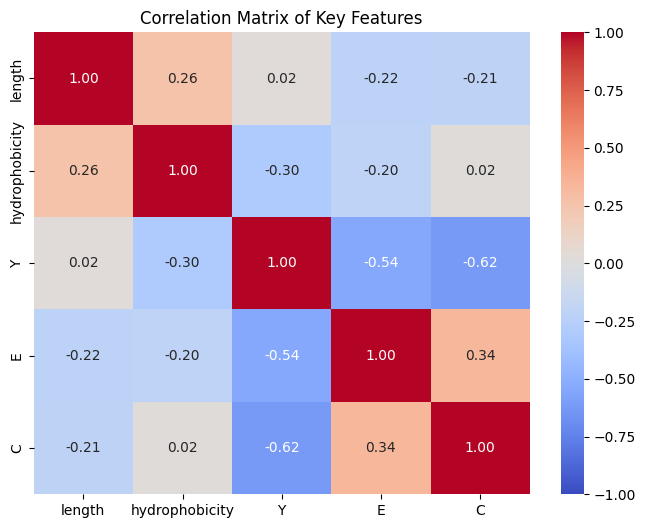

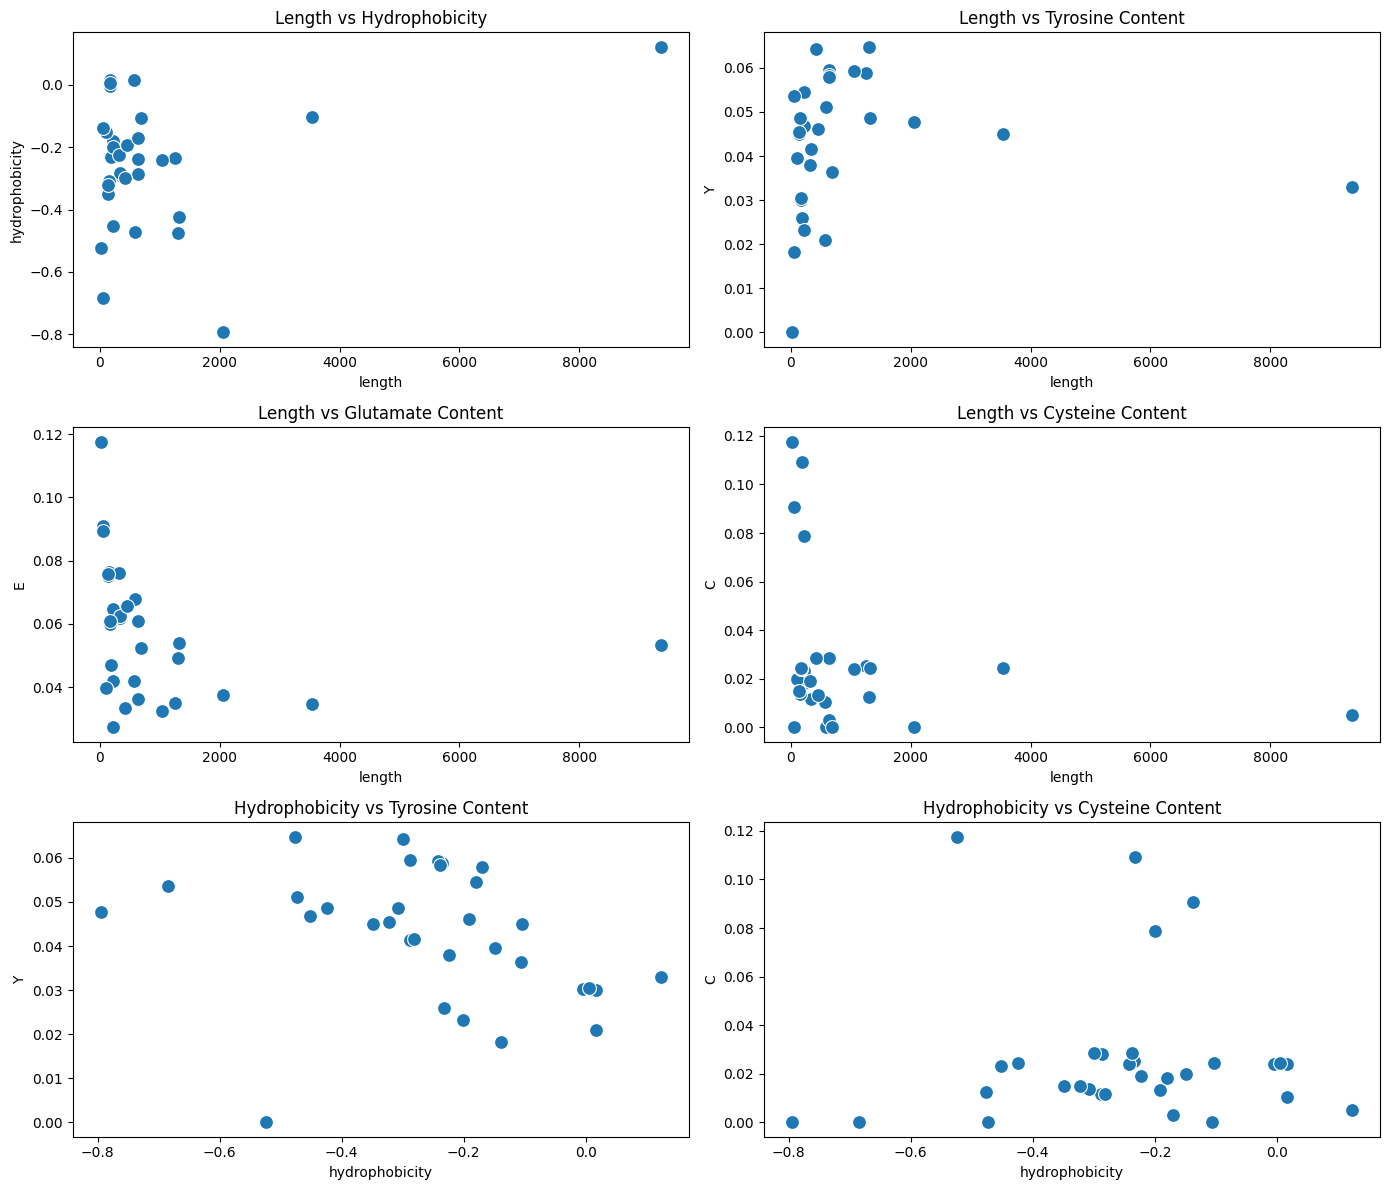

In [37]:
# Extract relevant features 
features_df = expanded_modeling_df[['length', 'hydrophobicity', 'Y', 'E', 'C']]

# Compute correlation matrix
correlation_matrix = features_df.corr()

# Plot the correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Key Features')
plt.savefig(os.path.join(save_dir, 'key_features_correlation_matrix.png'))
plt.show()

# Scatter plots to visualize relationships between features
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Length vs Hydrophobicity
sns.scatterplot(x=expanded_modeling_df['length'], y=expanded_modeling_df['hydrophobicity'], ax=axes[0, 0], s=100)
axes[0, 0].set_title('Length vs Hydrophobicity')

# Length vs Y (Tyrosine content)
sns.scatterplot(x=expanded_modeling_df['length'], y=expanded_modeling_df['Y'], ax=axes[0, 1], s=100)
axes[0, 1].set_title('Length vs Tyrosine Content')

# Length vs E (Glutamate content)
sns.scatterplot(x=expanded_modeling_df['length'], y=expanded_modeling_df['E'], ax=axes[1, 0], s=100)
axes[1, 0].set_title('Length vs Glutamate Content')

# Length vs C (Cysteine content)
sns.scatterplot(x=expanded_modeling_df['length'], y=expanded_modeling_df['C'], ax=axes[1, 1], s=100)
axes[1, 1].set_title('Length vs Cysteine Content')

# Hydrophobicity vs Y (Tyrosine content)
sns.scatterplot(x=expanded_modeling_df['hydrophobicity'], y=expanded_modeling_df['Y'], ax=axes[2, 0], s=100)
axes[2, 0].set_title('Hydrophobicity vs Tyrosine Content')

# Hydrophobicity vs C (Cysteine content)
sns.scatterplot(x=expanded_modeling_df['hydrophobicity'], y=expanded_modeling_df['C'], ax=axes[2, 1], s=100)
axes[2, 1].set_title('Hydrophobicity vs Cysteine Content')


# Adjust layout
plt.tight_layout()
plt.savefig(os.path.join(save_dir,'correlation_scatter_plots.png'))
plt.show()


## Comparing Different Features of Peptides/Proteins:

**Length vs. Hydrophobicity:** Shows if longer peptides are generally more or less hydrophobic, potentially impacting stability or interactions.
- **Length vs. Tyrosine (Y) Content:** Reveals if tyrosine (aromatic AA) abundance depends on peptide length.
- **Length vs. Glutamate (E) Content:** Indicates if longer peptides tend to have more glutamate (polar AA), influencing charge or structure.
- **Length vs. Cysteine (C) Content:** Shows if cysteine (forms disulfide bonds) frequency correlates with length, potentially relating to structural stability.
- **Hydrophobicity vs. Tyrosine (Y) Content:** Examines if more hydrophobic peptides tend to have more tyrosine (aromatic AA).
- **Hydrophobicity vs. Cysteine (C) Content:** Looks for a relationship between hydrophobicity and cysteine presence, possibly linked to folding or stability.